### Compare YOLOv8n, v11n, and v12n Inference Speed and Confidence on Recorded Video


Running inference with YOLOv8n...
YOLOv8n: Avg Confidence = 0.501
YOLOv8n: 381 frames in 10.64s → 35.81 FPS

Running inference with YOLOv11n...
YOLOv11n: Avg Confidence = 0.511
YOLOv11n: 381 frames in 11.13s → 34.23 FPS

Running inference with YOLOv12n...
YOLOv12n: Avg Confidence = 0.502
YOLOv12n: 381 frames in 12.55s → 30.36 FPS


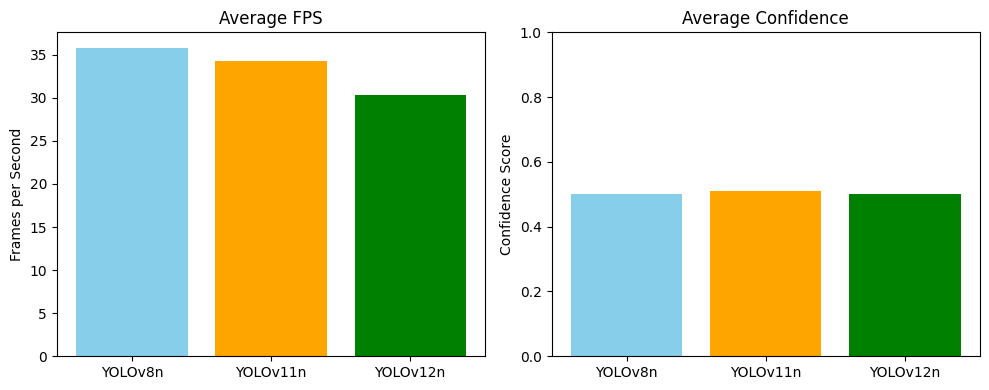

In [4]:
from ultralytics import YOLO
import cv2
import time
import matplotlib.pyplot as plt

# Load models (will download if not found)
models = {
    "YOLOv8n": YOLO("yolov8n.pt"),
    "YOLOv11n": YOLO("yolo11n.pt"),
    "YOLOv12n": YOLO("yolo12n.pt")
}

# Input video
video_path = "sample.mp4"
cap = cv2.VideoCapture(video_path)

# Get video properties
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(3))
height = int(cap.get(4))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Rewind video to the beginning after reading its properties
cap.release()

# Store results
fps_results = {}
confidence_scores = {}
total_confidence = 0
total_boxes = 0

for name, model in models.items():
    print(f"\nRunning inference with {name}...")

    cap = cv2.VideoCapture(video_path)
    out = cv2.VideoWriter(f"output_{name}.mp4",
                          cv2.VideoWriter_fourcc(*'mp4v'),
                          fps, (width, height))

    frame_idx = 0
    start_time = time.time()

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        results = model(frame, verbose=False)
        boxes = results[0].boxes

        if boxes is not None and boxes.conf is not None:
            total_confidence += boxes.conf.sum().item()
            total_boxes += boxes.conf.shape[0]

        # Annotated frame
        annotated = results[0].plot()
        out.write(annotated)
        frame_idx += 1

    end_time = time.time()
    total_time = end_time - start_time
    avg_fps = frame_idx / total_time

    avg_conf = total_confidence / total_boxes if total_boxes else 0
    confidence_scores[name] = avg_conf
    print(f"{name}: Avg Confidence = {avg_conf:.3f}")

    # Store metrics
    fps_results[name] = avg_fps
    confidence_scores[name] = avg_conf
    

    cap.release()
    out.release()
    print(f"{name}: {frame_idx} frames in {total_time:.2f}s → {avg_fps:.2f} FPS")

plt.figure(figsize=(10, 4))

# Plot FPS
plt.subplot(1, 2, 1)
plt.bar(fps_results.keys(), fps_results.values(), color=['skyblue', 'orange', 'green'])
plt.title("Average FPS")
plt.ylabel("Frames per Second")

# Plot Average Confidence
plt.subplot(1, 2, 2)
plt.bar(confidence_scores.keys(), confidence_scores.values(), color=['skyblue', 'orange', 'green'])
plt.title("Average Confidence")
plt.ylim(0, 1)  # Confidence scores range between 0 and 1
plt.ylabel("Confidence Score")

plt.tight_layout()
plt.savefig("fps_confidence_comparison.png")
plt.show()

### Process and Convert WIDER FACE Annotations to YOLO Format

In [ ]:
import os
import shutil
import cv2

dataset_root = "."
splits = ['train', 'val']

for split in splits:
    annotation_path = os.path.join(dataset_root, f"wider_face_annotations/wider_face_{split}_bbx_gt.txt")
    image_base = os.path.join(dataset_root, f"WIDER_{split}/images")
    label_dir = os.path.join(dataset_root, f"labels/{split}")
    image_target_dir = os.path.join(dataset_root, f"images/{split}")
    os.makedirs(label_dir, exist_ok=True)
    os.makedirs(image_target_dir, exist_ok=True)

    with open(annotation_path, 'r') as f:
        lines = f.readlines()

    i = 0
    total_images = 0

    while i < len(lines):
        image_name = lines[i].strip()
        i += 1
        if i >= len(lines):
            break

        try:
            face_count = int(lines[i].strip())
        except ValueError:
            print(f"Skipping corrupted entry at line {i}: {lines[i]}")
            continue
        i += 1

        image_path = os.path.join(image_base, image_name)
        target_image_path = os.path.join(image_target_dir, image_name)
        label_file_path = os.path.join(label_dir, image_name.replace(".jpg", ".txt"))

        try:
            img = cv2.imread(image_path)
            if img is None:
                raise ValueError("Corrupted image")
            h, w = img.shape[:2]
        except Exception as e:
            print(f"Skipping image (corrupt or missing): {image_path}")
            i += face_count
            continue

        os.makedirs(os.path.dirname(label_file_path), exist_ok=True)
        os.makedirs(os.path.dirname(target_image_path), exist_ok=True)

        shutil.copy(image_path, target_image_path)

        with open(label_file_path, "w") as label_file:
            for _ in range(face_count):
                parts = list(map(int, lines[i].strip().split()))
                x, y, bw, bh = parts[0], parts[1], parts[2], parts[3]

                if bw <= 0 or bh <= 0:
                    i += 1
                    continue

                x_center = (x + bw / 2) / w
                y_center = (y + bh / 2) / h
                width = bw / w
                height = bh / h

                label_file.write(f"0 {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")
                i += 1

        total_images += 1

    print(f"Finished processing {total_images} images for {split} set.")


⚠️ Skipping corrupted entry at line 10424: 0--Parade/0_Parade_Parade_0_630.jpg

⚠️ Skipping corrupted entry at line 86539: 2--Demonstration/2_Demonstration_Political_Rally_2_414.jpg

⚠️ Skipping corrupted entry at line 133394: 39--Ice_Skating/39_Ice_Skating_iceskiing_39_195.jpg

⚠️ Skipping corrupted entry at line 145714: 46--Jockey/46_Jockey_Jockey_46_138.jpg

✅ Finished processing 12880 images for train set.
✅ Finished processing 3226 images for val set.


### Train a YOLOv8n Model on the WIDER FACE Dataset

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="widerface.yaml",
    epochs=100,
    imgsz=416,
    batch=16,
    freeze=13,
    workers=4
)

Ultralytics 8.3.161 🚀 Python-3.13.2 torch-2.7.1+cu126 CUDA:0 (NVIDIA GeForce GTX 1070, 8099MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=widerface.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=13, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train7, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=

train: Scanning /media/cseru/c7affc2f-7569-4a5f-af53-c40816938344/Shakil/4.2/Neural Networ and Deep Learning/labels/train/0--Parade.cache... 12880 images, 4 backgrounds, 0 corrupt: 100%|██████████| 12880/12880 [00:00<?, ?it/s]

train: /media/cseru/c7affc2f-7569-4a5f-af53-c40816938344/Shakil/4.2/Neural Networ and Deep Learning/images/train/2--Demonstration/2_Demonstration_Protesters_2_231.jpg: 1 duplicate labels removed
train: /media/cseru/c7affc2f-7569-4a5f-af53-c40816938344/Shakil/4.2/Neural Networ and Deep Learning/images/train/37--Soccer/37_Soccer_Soccer_37_851.jpg: 1 duplicate labels removed
train: /media/cseru/c7affc2f-7569-4a5f-af53-c40816938344/Shakil/4.2/Neural Networ and Deep Learning/images/train/7--Cheering/7_Cheering_Cheering_7_17.jpg: 1 duplicate labels removed


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 7.2±5.2 MB/s, size: 116.1 KB)


val: Scanning /media/cseru/c7affc2f-7569-4a5f-af53-c40816938344/Shakil/4.2/Neural Networ and Deep Learning/labels/val/0--Parade.cache... 3226 images, 4 backgrounds, 0 corrupt: 100%|██████████| 3226/3226 [00:00<?, ?it/s]

...

                   all       3226      39696      0.745      0.359      0.419      0.214

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


     42/100      6.16G       1.63     0.8473     0.9748        206        416: 100%|██████████| 805/805 [01:18<00:00, 10.28it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 101/101 [00:17<00:00,  5.89it/s]


                   all       3226      39696      0.751       0.36      0.419      0.215

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


     43/100      5.03G      1.623      0.841     0.9762        338        416:  97%|█████████▋| 779/805 [01:16<00:02, 10.21it/s]
Exception in thread Thread-23 (_pin_memory_loop):
Traceback (most recent call last):
  File "/home/cseru/miniconda3/lib/python3.13/threading.py", line 1041, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "/media/cseru/c7affc2f-7569-4a5f-af53-c40816938344/Shakil/4.2/Neural Networ and Deep Learning/YOLO/yolovenv/lib/python3.13/site-packages/ipykernel/ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
    ~~~~~~~~~~~~~~~~~~~~~^^^^^^
  File "/home/cseru/miniconda3/lib/python3.13/threading.py", line 992, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/media/cseru/c7affc2f-7569-4a5f-af53-c40816938344/Shakil/4.2/Neural Networ and Deep Learning/YOLO/yolovenv/lib/python3.13/site-packages/torch/utils/data/_utils/pin_memory.py", line 61, in _pin_memory_loop
    do_one_step()
    ~~

KeyboardInterrupt: 

### Run Inference on a Video with a Custom-Trained Mode

In [ ]:
from ultralytics import YOLO
import cv2
import time
import matplotlib.pyplot as plt

models = {
    "YOLOv8n": YOLO("best.pt"),
    # "YOLOv11n": YOLO("yolo11n.pt"),
    # "YOLOv12n": YOLO("yolo12n.pt")
}

video_path = "office.mp4"
cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(3))
height = int(cap.get(4))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

cap.release()

fps_results = {}
confidence_scores = {}
total_confidence = 0
total_boxes = 0

for name, model in models.items():
    print(f"\nRunning inference with {name}...")

    cap = cv2.VideoCapture(video_path)
    out = cv2.VideoWriter(f"output_{name}.mp4", cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

    frame_idx = 0
    start_time = time.time()

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        results = model(frame, verbose=False)
        boxes = results[0].boxes

        if boxes is not None and boxes.conf is not None:
            total_confidence += boxes.conf.sum().item()
            total_boxes += boxes.conf.shape[0]

        annotated = results[0].plot()
        out.write(annotated)
        frame_idx += 1

    end_time = time.time()
    total_time = end_time - start_time
    avg_fps = frame_idx / total_time

    avg_conf = total_confidence / total_boxes if total_boxes else 0
    confidence_scores[name] = avg_conf
    print(f"{name}: Avg Confidence = {avg_conf:.3f}")

    fps_results[name] = avg_fps
    confidence_scores[name] = avg_conf
    

    cap.release()
    out.release()
    print(f"{name}: {frame_idx} frames in {total_time:.2f}s → {avg_fps:.2f} FPS")


🔍 Running inference with YOLOv8n...
YOLOv8n: Avg Confidence = 0.817
✅ YOLOv8n: 1141 frames in 13.54s → 84.27 FPS


### Generate Predictions for the Validation Set in WIDER Evaluation Format

In [ ]:
import os
from PIL import Image
from tqdm import tqdm
from ultralytics import YOLO

WEIGHTS_PATH = 'best.pt'
IMAGES_VAL_PATH = 'images/val'
PRED_FOLDER = 'my_model_predictions'

def generate_predictions_with_nested_structure(weights_path, images_folder, output_folder):
    if not os.path.exists(weights_path):
        print(f"FATAL ERROR: Weights file not found at '{weights_path}'.")
        return False
        
    print(f"--- Step 1: Generating Predictions with Correct Directory Structure ---")
    model = YOLO(weights_path)
    if os.path.exists(output_folder):
        !rm -rf {output_folder}
    os.makedirs(output_folder, exist_ok=True)

    image_paths = []
    for dirpath, _, filenames in os.walk(images_folder):
        for filename in filenames:
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(dirpath, filename))
    
    print(f"Running inference on {len(image_paths)} validation images...")
    for image_path in tqdm(image_paths):
        results = model(image_path, verbose=False)
        result = results[0]

        relative_path = os.path.relpath(image_path, images_folder)
        pred_file_path = os.path.join(output_folder, os.path.splitext(relative_path)[0] + ".txt")        
        os.makedirs(os.path.dirname(pred_file_path), exist_ok=True)
        
        with open(pred_file_path, 'w') as f:
            f.write(relative_path.replace('\\', '/') + '\n')
            f.write(str(len(result.boxes)) + '\n')
            for box in result.boxes:
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                w = x2 - x1
                h = y2 - y1
                score = box.conf[0].item()
                f.write(f"{x1:.3f} {y1:.3f} {w:.3f} {h:.3f} {score:.4f}\n")
    
    print("Prediction file generation complete with correct nested structure.")
    return True

generate_predictions_with_nested_structure(WEIGHTS_PATH, IMAGES_VAL_PATH, PRED_FOLDER)

--- Step 1: Generating Predictions with Correct Directory Structure ---
Running inference on 3226 validation images...


100%|██████████| 3226/3226 [00:42<00:00, 75.36it/s]


Prediction file generation complete with correct nested structure.


True

In [12]:
!pip install ensemble-boxes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 4.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 3.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ensemble-boxes]m [ensemble-boxes]


In [13]:
!python evaluation.py \
    -w best.pt \
    -p my_model_predictions \
    -e images/val

Testing on single-scale:
100%|███████████████████████████████████████████| 61/61 [01:18<00:00,  1.29s/it]


In [4]:
import os
os.chdir('./Evaluation')

In [2]:
!pip install ensemble_boxes

  Using cached ensemble_boxes-1.0.9-py3-none-any.whl.metadata (728 bytes)
Using cached ensemble_boxes-1.0.9-py3-none-any.whl (23 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 4.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 3.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ensemble_boxes]m [ensemble_boxes]


In [13]:
!pwd

/media/cseru/c7affc2f-7569-4a5f-af53-c40816938344/Shakil/4.2/Neural Networ and Deep Learning/Evaluation


In [11]:
!pip uninstall bbox -y

Found existing installation: bbox 0.9.4
Uninstalling bbox-0.9.4:
  Successfully uninstalled bbox-0.9.4


### Run Official WIDER FACE Evaluation Script

In [ ]:
import os
import sys
PRED_FOLDER = 'my_model_predictions'
GT_DIRECTORY_PATH = 'ground_truth'
TOOLBOX_FOLDER = 'Evaluation'
required_gt_file = os.path.join(GT_DIRECTORY_PATH, 'wider_face_val_bbx_gt.txt')
so_files = !find {TOOLBOX_FOLDER}/bbox -name "*.so"

if not so_files:
    print(f"ERROR: Compiled module (.so file) not found. Please build it first.")
elif not os.path.exists(PRED_FOLDER):
    print(f"ERROR: Prediction folder '{PRED_FOLDER}' not found.")
elif not os.path.exists(required_gt_file):
    print(f"ERROR: The required ground truth file was not found at '{required_gt_file}'.")
else:
    evaluation_script_path = os.path.join(TOOLBOX_FOLDER, 'evaluation.py')
    
    !python {evaluation_script_path} -p {PRED_FOLDER} -g {GT_DIRECTORY_PATH}

Processing hard: 100%|██████████████████████████| 61/61 [00:14<00:00,  4.20it/s]
==================== Results ====================
Easy   Val AP: 0.9065122168260222
Medium Val AP: 0.8593496869969945
Hard   Val AP: 0.6007832738334945
